# SSP CO Data Release Table Construction

This notebook builds per-release SSP cosmology data products by combining pfscoadds (2DRP output) info, processed obslog info, `lam1d` / 1DRP results, and the SSP CO target catalog.

Edit the release setup cell below for the run/release you want to process, especially `pfs_base_dir`, `semester_code`, `collections`, `combination`, and the 1DRP configuration path/name. The current example is configured for `run25_February2026`.

Main inputs:
- 2DRP output under the selected PFS program/release directory
- Processed obslog table, currently `./co_nov2025.csv` (run25)
- 1DRP output for a given config, default = "modified" for cosmology, i.e. up to 960nm only
- SSP CO target catalog, currently `s23b_ssp_co_targets_bgmasked.fits`

Main outputs:
- `{release}_gr_info.ecsv`: object-group-level (e.g. per-pointing-level) release and obslog summary
- `{release}_coadd_obs_info.ecsv`: object-level coadd observation summary
- `ssp_co_targets_{release}_lam1d_obs_combined.ecsv`: final joined target, 1DRP, coadd, and group-info table


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, Column
from astropy.table import join
from astropy.table import vstack
from pathlib import Path

from lsst.daf.butler import Butler
from pfs.datamodel import TargetType
from pfs.datamodel import FiberStatus
%matplotlib inline

from pfs.datamodel.pfsTargetSpectra import PfsTargetSpectra
from pfs.datamodel import PfsCoZCandidates, PfsZCandidates

from IPython.display import clear_output
from scipy.ndimage import uniform_filter1d
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import median_filter
from scipy import ndimage

# basice set up for one data release

In [2]:
catId = 10091 # catId for SSP Cosmology scientific targets (note: this includes ancillary targets as well)

# SP
#pfs_base_dir = "/shared/pfs/programs/"
# idark
pfs_base_dir = "/lustre/work/jingjing.shi/PFS_SSP/hscpfs.mtk.nao.ac.jp/fileaccess/pfs/programs/"

semester_code = 'S25B-OT02'
collections = ['run25_February2026'] # release collection
release = collections[0]

butler = Butler(pfs_base_dir + semester_code + '/2d/', collections=collections)
dataRef = list(butler.registry.queryDatasets('pfsCoadd'))
for i in range(len(dataRef)):
    print(dataRef[i])

combination = 'selected_run25' 

# get the object group map: objId and objGroup map 
# objId that belong to the same objGroup are saved in on pfsCoadd file; note this map is changing for different release
ogm = butler.get("objectGroupMap", combination=combination, cat_id=catId)

# note: here the objId are science fibers that are marked as good fibers
objid_release = ogm.objId
groupid_release = ogm.objGroup
nobj_release = len(objid_release)

print(f"There are {nobj_release} objects in run25, {len(np.unique(groupid_release))} groups.")

# get the unique groupid_release and rank them by ascending order of the value
unique_groupids = np.unique(groupid_release)
unique_groupids.sort()
print(f"Unique groupids: {unique_groupids}.")

pfsCoadd@{instrument: 'PFS', cat_id: 10091, combination: 'selected_run25', obj_group: 68} [sc=PfsObjectSpectra] (run=run25_February2026 id=dd471760-a109-4c9a-873b-e6df9f81b903)
pfsCoadd@{instrument: 'PFS', cat_id: 10091, combination: 'selected_run25', obj_group: 10} [sc=PfsObjectSpectra] (run=run25_February2026 id=43aafc98-0184-4c12-97f2-8b2c3a447614)
pfsCoadd@{instrument: 'PFS', cat_id: 10091, combination: 'selected_run25', obj_group: 8} [sc=PfsObjectSpectra] (run=run25_February2026 id=90ecd1e1-9b00-4931-9b8d-c48184457d5e)
pfsCoadd@{instrument: 'PFS', cat_id: 10091, combination: 'selected_run25', obj_group: 44} [sc=PfsObjectSpectra] (run=run25_February2026 id=2106d432-67ca-4416-b228-c5c3233629e7)
pfsCoadd@{instrument: 'PFS', cat_id: 10091, combination: 'selected_run25', obj_group: 51} [sc=PfsObjectSpectra] (run=run25_February2026 id=4d7f4fe8-3ccd-435c-a40a-92cc5edb95a3)
pfsCoadd@{instrument: 'PFS', cat_id: 10091, combination: 'selected_run25', obj_group: 65} [sc=PfsObjectSpectra] (run

## read obslog

In [ ]:
# https://github.com/jingssrs/pfs_co_data/tree/main/obslog/processed/
# e.g. obslog for run25
obslog_file = "./co_nov2025.csv" 
obslog = Table.read(obslog_file)
ppc_name_obslog = np.unique(obslog['sequence_name'])
print(f'obslog: {len(ppc_name_obslog)} pointings observed.')

'''
# for S25A
obslog_file_march = "./co_march2025.csv"
obslog_march = Table.read(obslog_file_march)
obslog_file_may = "./co_may2025.csv"
obslog_may = Table.read(obslog_file_may)
obslog_file_june = "./co_june2025.csv"
obslog_june = Table.read(obslog_file_june)

# here we combine the obslog of march, may, and june together for S25A
obslog = vstack([obslog_march, obslog_may, obslog_june])
'''

# map ppc_name to visit_id list in obslog
dict_obslog_visits = {}
for ppc_name in ppc_name_obslog:
    dict_obslog_visits[ppc_name] = obslog['visit_id'][obslog['sequence_name'] == ppc_name]

# process data

## sanity check

In [3]:
def get_objid_goodscience(butler, visit, return_config_badscience=False):
    '''
    Sanity check:
    Get objId of good science targets for a given visit. Optionally return the pfsConfig of bad science targets.
    '''
    pfsConfig = butler.get('pfsConfig', visit=visit)
    #print(f'visit = {visit}, length of pfsConfig = {len(pfsConfig)}.')
    
    pfsConfigGoodScience = pfsConfig.select(targetType = TargetType.SCIENCE, fiberStatus =  FiberStatus.GOOD)
    #print(f'Science target (good_fibers) = {len(pfsConfigGoodScience)}')

    pfsConfigBadScience = pfsConfig.select(targetType = TargetType.SCIENCE, fiberStatus =  ~FiberStatus.GOOD)
    #print(f'Science target (bad_fibers) = {len(pfsConfigBadScience)}')

    objIdGoodScience = []
    for index in range(len(pfsConfigGoodScience)):
        catId = pfsConfigGoodScience.catId[index]  
        objId = pfsConfigGoodScience.objId[index] 
        objIdGoodScience.append(objId)
    objIdGoodScience = np.array(objIdGoodScience)

    if return_config_badscience:
        return objIdGoodScience, pfsConfigBadScience
    else:
        return objIdGoodScience


## get ppc_name, visits_coadds for each groupid & observation info for each objid

In [6]:
# time consuming sanity check 
sanity_check = True

# groupid_release and ppc_name (from obslog) map
gr_ids = []
ppc_names = []
visits_obslog_list = []

# coaddes-level info per objId
objid_coadds = []
visits_coadds = []
spectrograph_coadds = []
pfi_offset_coadds = []
t_exp_total_coadds = []
eet_r_coadds = []
seeing_mean_coadds = []
transparency_mean_coadds = []
# TODO: maybe airmass instead of altitude?
altitude_mean_coadds = []

# loop through each groupid
for gid in unique_groupids:
    mask_gr = (groupid_release == gid)
    objid_gr = objid_release[mask_gr]

    # Get coadd for this group
    pfsCoadd = butler.get(
        "pfsCoadd",
        combination=combination,
        cat_id=catId,
        obj_group=int(gid),
    )

    # get visits_coadds, t_exp_total, spectrograph, pfi_offset for each objId in this group
    for objId in objid_gr:
        pfsObject = pfsCoadd[catId, objId]
        objid_coadds.append(objId)
        
        visits_objId = np.unique(pfsObject.observations.visit).astype(int).tolist()
        visits_coadds.append(visits_objId)

        spectrograph_coadds.append(np.unique(pfsObject.observations.spectrograph))
        tmp = pfsObject.observations.pfiCenter - pfsObject.observations.pfiNominal 
        pfi_offset_coadds.append(np.mean(np.sqrt(tmp[:, 0]**2. + tmp[:, 1]**2.))) # in mm
        
        idx_obslog = np.isin(obslog['visit_id'], visits_objId)
        t_exp_total_coadds.append(obslog['avg_exptime'][idx_obslog].sum())
        eet_r_coadds.append(obslog['eet_r'][idx_obslog].sum())
        seeing_mean_coadds.append(obslog['seeing_median'][idx_obslog].mean())
        transparency_mean_coadds.append(obslog['transparency_median'][idx_obslog].mean())
        altitude_mean_coadds.append(obslog['avg_altitude'][idx_obslog].mean())


    # get ppc_name (unique for each pointing), and visits_obslog for this group
    one_visit = visits_objId[0]
    ppc_name = obslog["sequence_name"][obslog["visit_id"] == one_visit][0]

    # visits in obslog per ppc_name, 
    # note visits_obslog can be different from visits_coadds because some visits can fail 2D QA and thus are not included in the coadds
    visits_obslog = dict_obslog_visits[ppc_name]

    # check how many bad science objects exist for one visit
    # You can skip this check since it can be time consuming!
    if sanity_check:
        # note here I only check for one visit.
        # if the visits are done in different fiber configurations, objIdGoodScience can change for different fiber configurations, 
        # thus objid_gr may not match objIdGoodScience exactly, but objIdGoodScience of one visit should be a subset of objid_gr.
        objIdGoodScience, pfsConfigBadScience = get_objid_goodscience(butler, one_visit, return_config_badscience=True)
        # note that bad ~ 100, good ~ 1700; and bad pfscoadds are not released
        print(f'For gid={gid}, ppc_name={ppc_name}, visit={one_visit}: bad science objects = {len(pfsConfigBadScience)}, good science objects = {len(objIdGoodScience)}.')

        # check if objIdGoodScience matches objid_gr
        set_goodscience = set(objIdGoodScience)
        set_objid_gr = set(objid_gr)
        if set_goodscience == set_objid_gr:
            print(f'Verified: objIdGoodScience matches objid_gr for gid={gid}, ppc_name={ppc_name}.')
        else:
            # this is the case if the visits_coadds include different fiber configurations 
            print(f'Discrepancy found for gid={gid}, ppc_name={ppc_name}: len(set_goodscience)={len(set_goodscience)}, len(set_objid_gr)={len(set_objid_gr)}.')

    # store per groupid info
    gr_ids.append(int(gid))
    ppc_names.append(ppc_name)
    visits_obslog_list.append(list(visits_obslog))
    

Unique groupids: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82].
For gid=1, ppc_name=SSP_CO_Spring_8h_20_v1, visit=134722: bad science objects = 106, good science objects = 1734.
Verified: objIdGoodScience matches objid_gr for gid=1, ppc_name=SSP_CO_Spring_8h_20_v1.
For gid=2, ppc_name=SSP_CO_Autumn_1h_34_v2, visit=133893: bad science objects = 79, good science objects = 1655.
Verified: objIdGoodScience matches objid_gr for gid=2, ppc_name=SSP_CO_Autumn_1h_34_v2.
For gid=3, ppc_name=SSP_CO_Autumn_2h_46_v2, visit=135221: bad science objects = 114, good science objects = 1649.
Verified: objIdGoodScience matches objid_gr for gid=3, ppc_name=SSP_CO_Autumn_2h_46_v2.
For gid=4, ppc_name=SSP_CO_Autumn_2h_71_v1, visit=133899: bad science objects = 82, good science objects = 1708.
Verified: obj

In [7]:
# save the group info 
visits_obslog_list = [[int(v) for v in row] for row in visits_obslog_list]

release_gr_info = Table()
release_gr_info["gr_id"] = [int(g) for g in gr_ids]
release_gr_info["ppc_name"] = ppc_names
release_gr_info["visits_obslog"] = Column(visits_obslog_list, dtype=object)

release_gr_info.write(f"{release}_gr_info.ecsv", overwrite=True)

# check if ppc_names match ppc_name_obslog
for ppc_name in ppc_name_obslog:
    if ppc_name not in ppc_names:
        print(f'ppc_name {ppc_name} from obslog not found in coadds!')

ppc_name SSP_CO_Autumn_22h_30_v1 from obslog not found in coadds!
ppc_name SSP_CO_Autumn_2h_66_v1 from obslog not found in coadds!


In [8]:
release_gr_info[:10]

gr_id,ppc_name,visits_obslog
int64,str23,object
1,SSP_CO_Spring_8h_20_v1,"[134723, 134722]"
2,SSP_CO_Autumn_1h_34_v2,"[133894, 133893]"
3,SSP_CO_Autumn_2h_46_v2,"[135222, 135221]"
4,SSP_CO_Autumn_2h_71_v1,"[133900, 133899]"
5,SSP_CO_Spring_9h_35_v1,"[134454, 134453]"
6,SSP_CO_Autumn_1h_33_v1,"[134663, 134662]"
7,SSP_CO_Autumn_2h_69_v1,"[134839, 134838]"
8,SSP_CO_Spring_9h_33_v2,"[134705, 134704]"
9,SSP_CO_Spring_9h_41_v2,"[134439, 134438, 134866, 134865]"


In [9]:
# save the coadd-level info per objId
release_coadd_obs_info = Table()
release_coadd_obs_info["objId"] = objid_coadds
release_coadd_obs_info["visits"] = Column(visits_coadds, dtype=object)
release_coadd_obs_info["spectrograph"] = spectrograph_coadds
release_coadd_obs_info["pfi_offset_mm"] = pfi_offset_coadds
release_coadd_obs_info["t_exp_total"] = t_exp_total_coadds
release_coadd_obs_info["eet_r"] = eet_r_coadds
release_coadd_obs_info["seeing_mean"] = seeing_mean_coadds
release_coadd_obs_info["transparency_mean"] = transparency_mean_coadds
release_coadd_obs_info["altitude_mean"] = altitude_mean_coadds

release_coadd_obs_info.write(f"{release}_coadd_obs_info.ecsv", overwrite=True)

In [20]:
# make sure the objId in release_coadd_obs_info matches objid_release
set_coadd_obs_info = set(release_coadd_obs_info["objId"])
set_objid_release = set(objid_release)
if set_coadd_obs_info == set_objid_release:
    print(f'Verified: objId in release_coadd_obs_info matches objid_release for {release}.')
else:
    print(f'Wrong! objId in release_coadd_obs_info does not match objid_release for {release}.')

Verified: objId in release_coadd_obs_info matches objid_release for run25_February2026.


In [10]:
# preview the coadd_obs_info table
release_coadd_obs_info[:5]

objId,visits,spectrograph,pfi_offset_mm,t_exp_total,eet_r,seeing_mean,transparency_mean,altitude_mean
int64,object,int16[1],float64,float64,float64,float64,float64,float64
3079594703461817088,"[134722, 134723]",4,0.010597347096828108,751.9984970092773,1249.6613499999999,0.6126983500000001,0.88869317,73.09068534982597
3079597963341871360,"[134722, 134723]",1,0.0012078803834801113,751.9984970092773,1249.6613499999999,0.6126983500000001,0.88869317,73.09068534982597
3079598173795128832,"[134722, 134723]",1,0.0035709560203531,751.9984970092773,1249.6613499999999,0.6126983500000001,0.88869317,73.09068534982597
3079598272580812928,"[134722, 134723]",1,0.007140102477957765,751.9984970092773,1249.6613499999999,0.6126983500000001,0.88869317,73.09068534982597
3079598345593827584,"[134722, 134723]",1,0.00675739569563833,751.9984970092773,1249.6613499999999,0.6126983500000001,0.88869317,73.09068534982597


# 1drp output

In [11]:
# read the group info and coadd-level info
release_gr_info = Table.read(f"{release}_gr_info.ecsv")
release_coadd_obs_info = Table.read(f"{release}_coadd_obs_info.ecsv")

In [13]:
# add two new columns: nobj_coadds, nobj_lam1d to the gr_info table
release_gr_info['nobj_coadds'] = 0
release_gr_info['nobj_lam1d'] = 0

config_1drp = "modified" # [400-960]nm; "default" - nir included
# get 1drp results for each group id
lam1d_release = []
for gid in unique_groupids:
    fn_lam1d = f"{pfs_base_dir}/{semester_code}/lam1d/{release}/{config_1drp}/10091_{gid}/data/pfsCoZcandidates-10091.fits"
    #print(f"gid = {gid}: {fn_lam1d}")
    hdul = fits.open(fn_lam1d)
    
    lam1d_basic = hdul['TARGET'].data
    lam1d_classification = hdul['CLASSIFICATION'].data
    lam1d_galaxy = hdul['GALAXY_CANDIDATES'].data

    # 20260513 note: QUALITY and GALAXY_LINES only exist for cRank==0 solution
    lam1d_quality = hdul['QUALITY'].data
    lam1d_galaxy_lines = hdul['GALAXY_LINES'].data

    OII3726_line = lam1d_galaxy_lines[lam1d_galaxy_lines['lineName'] == '[OII]3726']
    OII3729_line = lam1d_galaxy_lines[lam1d_galaxy_lines['lineName'] == '[OII]3729']
    
    lam1d_basic_table = Table(lam1d_basic)
    lam1d_classification_table = Table(lam1d_classification)
    lam1d_galaxy_table = Table(lam1d_galaxy[lam1d_galaxy['cRank'] == 0])
    lam1d_quality_table = Table(lam1d_quality)
    
    lam1d_combined = join(lam1d_basic_table, lam1d_classification_table, keys='targetId')
    lam1d_combined = join(lam1d_combined, lam1d_galaxy_table, keys='targetId')
    lam1d_combined = join(lam1d_combined, lam1d_quality_table, keys='targetId')

    OII3726_line_table = Table(OII3726_line)
    for col in OII3726_line_table.colnames:
        if col != 'targetId':
            OII3726_line_table.rename_column(col, f"{col}_OII3726")
    OII3729_line_table = Table(OII3729_line)
    for col in OII3729_line_table.colnames:
        if col != 'targetId':
            OII3729_line_table.rename_column(col, f"{col}_OII3729")

    # keep all rows from lam1d_combined and append OII3726 columns when matched by targetId
    lam1d_combined = join(lam1d_combined, OII3726_line_table, keys='targetId', join_type='left')
    lam1d_combined = join(lam1d_combined, OII3729_line_table, keys='targetId', join_type='left')

    lam1d_release.append(lam1d_combined)

    # check number of lam1d entries vs number of objects in this group
    mask_gr = (groupid_release == gid)
    objid_gr = objid_release[mask_gr]

    nobj_lam1d = len(lam1d_combined)
    nobj_coadds = len(objid_gr)

    # update the gr_info table
    row_index = np.where(release_gr_info['gr_id'] == int(gid))[0][0]
    release_gr_info['nobj_lam1d'][row_index] = nobj_lam1d
    release_gr_info['nobj_coadds'][row_index] = nobj_coadds

lam1d_release = vstack(lam1d_release, join_type='outer')  # Fills missing columns with masked values
print(f"There are {len(lam1d_release)} entries in 1drp for {release}, {len(objid_release)} objects in coadds.")

# update gr_info table
release_gr_info.write(f"{release}_gr_info.ecsv", overwrite=True)

There are 137873 entries in 1drp for run25_February2026, 140447 objects in coadds.


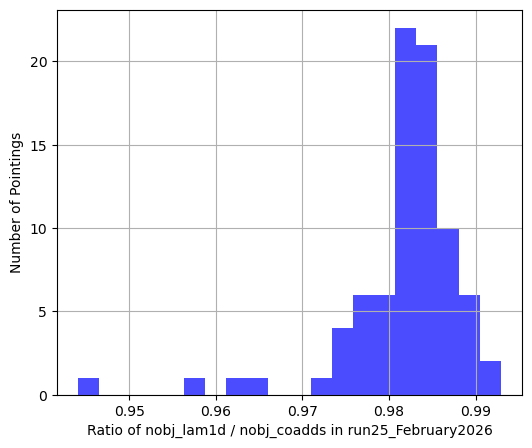

In [14]:
# plot the ratio of nobj_lam1d / nobj_coadds
ratios = release_gr_info['nobj_lam1d'] / release_gr_info['nobj_coadds']
plt.figure(figsize=(6,5))
plt.hist(ratios, bins=20, color='blue', alpha=0.7)
plt.xlabel(f'Ratio of nobj_lam1d / nobj_coadds in {release}')
plt.ylabel('Number of Pointings')
plt.grid()
plt.show()  
plt.close()

In [15]:
lam1d_release.colnames

['targetId',
 'catId',
 'tract',
 'patch',
 'objId',
 'nVisit',
 'visitHash',
 'ra',
 'dec',
 'targetType',
 'class',
 'probaGalaxy',
 'probaQSO',
 'probaStar',
 'cRank',
 'redshift',
 'redshiftError',
 'redshiftProba',
 'subClass',
 'continuumFile',
 'lineCatalogRatioFile',
 'emissionVelocity',
 'absorptionVelocity',
 'continuumReducedLeastSquare',
 'continuumPValue',
 'continuumResidualsMean',
 'continuumResidualsStd',
 'continuumResidualsSkewness',
 'continuumResidualsKurtosis',
 'continuumResidualsKs',
 'continuumResidualsKsStd',
 'continuumResidualsKsStdMean',
 'continuumResidualsAnderson',
 'reducedLeastSquare',
 'pValue',
 'residualsMean',
 'residualsStd',
 'residualsSkewness',
 'residualsKurtosis',
 'residualsKs',
 'residualsKsStd',
 'residualsKsStdMean',
 'residualsAnderson',
 'modelId',
 'nbPixels',
 'galaxyOIIRatio',
 'galaxyOII3726Snr',
 'galaxyOII3729Snr',
 'qsoOIIRatio',
 'qsoOII3726Snr',
 'qsoOII3729Snr',
 'lineName_OII3726',
 'lineWave_OII3726',
 'lineZ_OII3726',
 'line

# get the combined table: cross match ssp_co_targets table with this release 1drp results, and coadds_obs_info

In [ ]:
# read the cosmology targets (cosmology targets with bright star mask and bright galaxy mask), target status is updated after each run 
#fn_ssp_co_targets = "./s23b_ssp_co_targets_bgmasked.fits"

fn_ssp_co_targets = "/lustre/work/jingjing.shi/pfs_co_fa/data_proc/s23b_wide/ssp_co_targets/s23b_ssp_co_targets_bgmasked.fits"
ssp_co_targets = Table.read(fn_ssp_co_targets)

In [19]:
# get the ssp_co_targets that have pfsCoadds 
mask_release = np.isin(ssp_co_targets['object_id'], objid_release)
ssp_co_targets_release = ssp_co_targets[mask_release]
print(f'There are {len(ssp_co_targets_release)} cosmology targets (after bright star/galaxy mask) that has coadds in {release}.')

# join ssp_co_targets_release with lam1d_release on object_id and objId
ssp_co_targets_release_lam1d = join(
    ssp_co_targets_release,
    lam1d_release,
    keys_left='object_id',
    keys_right='objId',
    join_type='left'
)
print(f'After joining with 1drp, there are {len(ssp_co_targets_release_lam1d)} entries (not all have 1drp data).')


# remove the ra_2, dec_2, tract_2, patch_2 columns that are duplicated from the join; 
# keep the ra_1, dec_1, tract_1, patch_1 columns that are from ssp_co_targets_release
cols_to_remove = ['ra_2', 'dec_2', 'tract_2', 'patch_2']
ssp_co_targets_release_lam1d.remove_columns(cols_to_remove)

# rename ra_1, dec_1, tract_1, patch_1 to ra, dec, tract, patch
ssp_co_targets_release_lam1d.rename_column('ra_1', 'ra')
ssp_co_targets_release_lam1d.rename_column('dec_1', 'dec')
ssp_co_targets_release_lam1d.rename_column('tract_1', 'tract')        
ssp_co_targets_release_lam1d.rename_column('patch_1', 'patch')

# join with release_coadds_obs_info on object_id and objId to get the coadd-level info for each target
ssp_co_targets_release_lam1d_obs = join(
    ssp_co_targets_release_lam1d,
    release_coadd_obs_info,
    keys_left='object_id',
    keys_right='objId',
    join_type='left'
)   

# create a table that includes objid, groupid, ppc_name
obj_group = Table()
obj_group['object_id'] = objid_release
obj_group['gr_id'] = groupid_release
obj_group_info = join(
    obj_group,
    release_gr_info,
    keys='gr_id',
    join_type='left'
)

# join ssp_co_targets_release_lam1d with obj_group_info on object_id
ssp_co_targets_release_lam1d_obs_combined = join(
    ssp_co_targets_release_lam1d_obs,
    obj_group_info,
    keys='object_id',
    join_type='left'
)

# save the final table
ssp_co_targets_release_lam1d_obs_combined.write(f"ssp_co_targets_{release}_lam1d_obs_combined.ecsv", overwrite=True)
print(f'Saved the combined table in {release} that has {len(ssp_co_targets_release_lam1d_obs_combined)} entries.')

# get the entries that does not have lam1d info
mask_no_lam1d = ssp_co_targets_release_lam1d_obs_combined['redshift'].mask
ssp_co_targets_release_no_lam1d = ssp_co_targets_release_lam1d_obs_combined[mask_no_lam1d]
print(f'There are {len(ssp_co_targets_release_no_lam1d)} cosmology coadds that do not have lam1d info in {release}.')

There are 123158 cosmology targets (after bright star/galaxy mask) that has coadds in run25_February2026.
After joining with 1drp, there are 123158 entries (not all have 1drp data).
Saved the combined table in run25_February2026 that has 123158 entries.
There are 2304 cosmology coadds that do not have lam1d info in run25_February2026.
